### [ 이진화/ 스레시홀딩 ] <hr>

- 방법1) 직접 임계값 변경하면서 최적값 찾기
- 방법2) 

In [1]:
## 모듈 로딩
import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")
import cv_utils

In [ ]:
IMG_FILE= '../Images/scaned_paper.jpg'
imgNP= cv2.imread(IMG_FILE, cv2.IMREAD_GRAYSCALE)
print(f'{imgNP.shape}, {imgNP.ndim}, {imgNP.dtype}')


(200, 300), 2, uint8


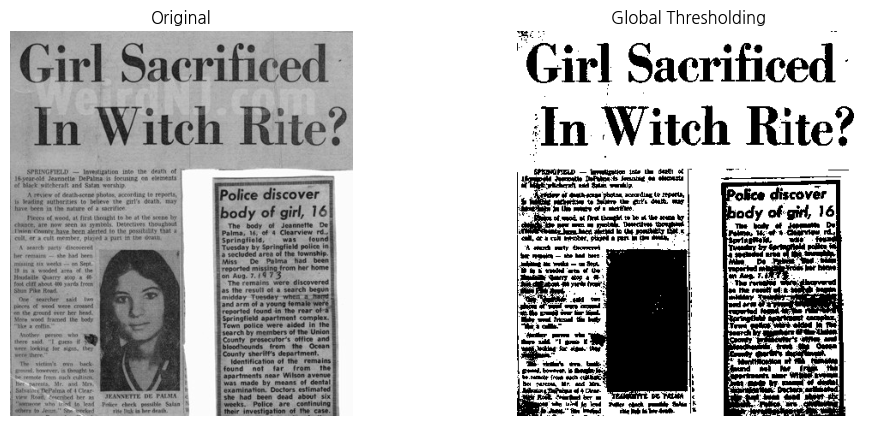

In [6]:

## ========================================
## 글로벌 스레시홀딩
## 전체 이미지에 하나의 임계값 적용
## ========================================

_, global_bin = cv2.threshold(
    imgNP,
    152,                 # 임계값
    255,                 # 임계값보다 클 때 적용할 값
    cv2.THRESH_BINARY
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(imgNP, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(global_bin, cmap='gray')
plt.title('Global Thresholding')
plt.axis('off')

plt.show()

오츠 알고리즘이 찾은 임계값: 131.0


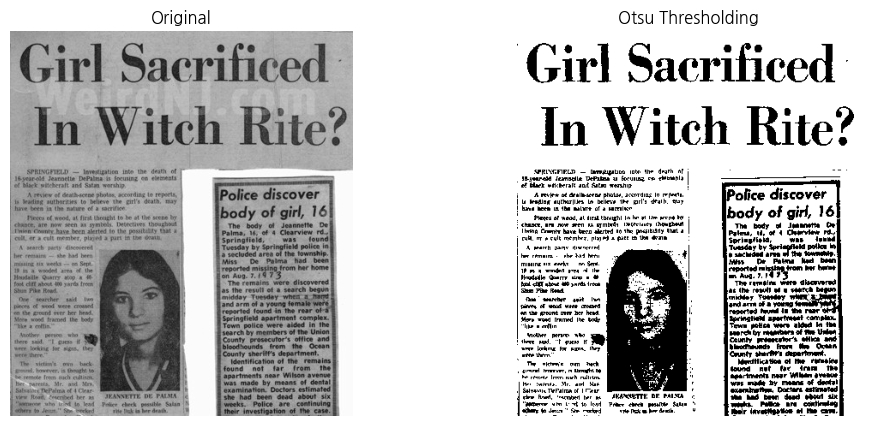

In [5]:

## ========================================
## 오츠 알고리즘 기반 이진화
## 자동으로 최적 임계값을 찾아 이진화
## ========================================

## 오츠 이진화
## threshold 값은 0으로 넣고,
## cv2.THRESH_OTSU를 같이 사용하면 자동으로 임계값을 찾음
ret, otsu_bin = cv2.threshold(
    imgNP,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print(f'오츠 알고리즘이 찾은 임계값: {ret}')

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(imgNP, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(otsu_bin, cmap='gray')
plt.title('Otsu Thresholding')
plt.axis('off')

plt.show()

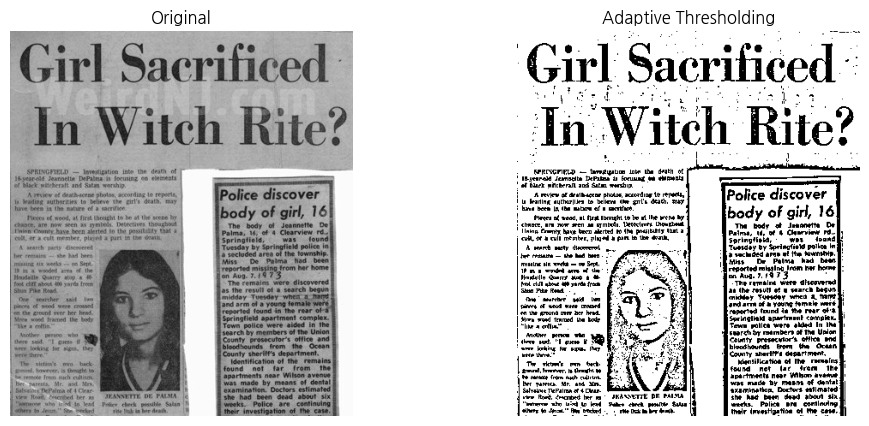

In [3]:

## ========================================
## 어댑티브 스레시홀딩
## 주변 픽셀을 기준으로 지역별 임계값 적용
## ========================================

adaptive_bin = cv2.adaptiveThreshold(
    imgNP,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    21,      # blockSize: 주변 영역 크기, 홀수만 가능
    10       # C: 평균/가중평균에서 뺄 값
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(imgNP, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(adaptive_bin, cmap='gray')
plt.title('Adaptive Thresholding')
plt.axis('off')

plt.show()

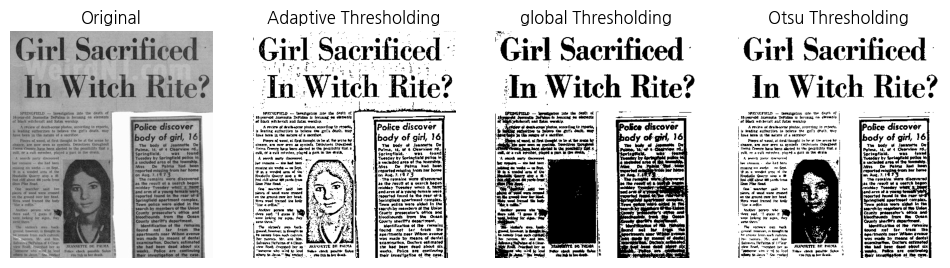

In [7]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 4, 1)
plt.imshow(imgNP, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(adaptive_bin, cmap='gray')
plt.title('Adaptive Thresholding')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(global_bin, cmap='gray')
plt.title('global Thresholding')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(otsu_bin, cmap='gray')
plt.title('Otsu Thresholding')
plt.axis('off')

plt.show()

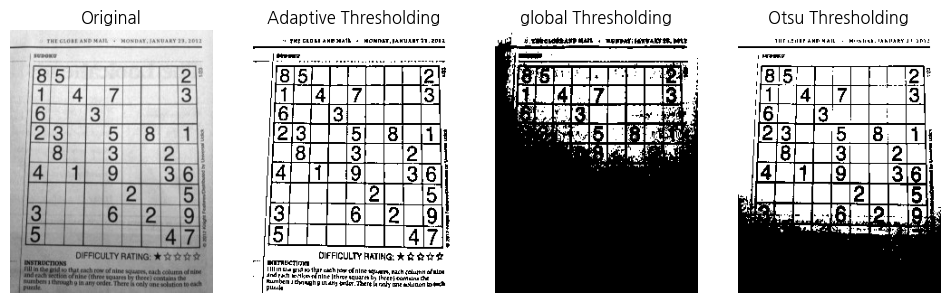

In [17]:
IMG_FILE1= '../Images/sudoku.jpg'
imgNP1= cv2.imread(IMG_FILE1, cv2.IMREAD_GRAYSCALE)

_, global_bin1 = cv2.threshold(imgNP1, 152, 255, cv2.THRESH_BINARY)
adaptive_bin1 = cv2.adaptiveThreshold(imgNP1, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 21, 10)
ret1, otsu_bin1 = cv2.threshold(imgNP, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


plt.figure(figsize=(12, 5))

plt.subplot(1, 4, 1)
plt.imshow(imgNP1, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(adaptive_bin1, cmap='gray')
plt.title('Adaptive Thresholding')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(global_bin1, cmap='gray')
plt.title('global Thresholding')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(otsu_bin1, cmap='gray')
plt.title('Otsu Thresholding')
plt.axis('off')

plt.show()